In [1]:
# install.packages("randomForest")
library(randomForest)
library(ggplot2)

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘ggplot2’


The following object is masked from ‘package:randomForest’:

    margin




In [5]:
df <- read.csv("../Data/hh.csv" , header=TRUE, sep = '|')
df<- subset(df,F_HHAsset_Value_Total!=0 )
df$M_HHAsset_Value_Total_lg <- log(df$M_HHAsset_Value_Total)
df$F_HHAsset_Value_Total_lg <- log(df$F_HHAsset_Value_Total)
df$Diff_ICV_HH_yn <- df$M_ICV_HH_yn - df$F_ICV_HH_yn
df$Diff_HHAsset_Value_Total <- df$M_HHAsset_Value_Total - df$F_HHAsset_Value_Total
df$Diff_Age <- df$M_Age - df$F_Age
df$Diff_HHSize <- df$M_HHSize - df$F_HHSize
df$Cell_Value_MF <- df$M_Cell_Value_Male - df$F_Cell_Value_Female
df$Cell_Value_M <- df$M_Cell_Value_Male - df$F_Cell_Value_Male
df$Cell_Value_F <- df$M_Cell_Value_Female- df$F_Cell_Value_Female
df$M_ZoneID_ft <- as.factor(df$M_ZoneID)
df$F_ZoneID_ft <- as.factor(df$F_ZoneID)
df$M_ZoneID_ft <- relevel(df$M_ZoneID_ft , ref = 3)
head(df)# [colnames(df)[c(1, 10)]]

,HH_Ind,HouseID,M_ZoneID,M_StateID,M_LgaID,M_LocalityID,M_EnumerationID,M_Individual_family_code,M_Sex,M_Age,⋯,F_HHAsset_Value_Total_lg,Diff_ICV_HH_yn,Diff_HHAsset_Value_Total,Diff_Age,Diff_HHSize,Cell_Value_MF,Cell_Value_M,Cell_Value_F,M_ZoneID_ft,F_ZoneID_ft
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>
1,0,112115,1,11,112,1121,11211,1,1,48,⋯,13.56923,0,437396,3,0,10110,14610,5388,1,1
2,1,112213,1,11,112,1122,11221,1,1,60,⋯,13.62193,0,4611000,0,0,8000,8000,8000,1,1
3,2,112214,1,11,112,1122,11221,1,1,77,⋯,16.20558,0,-3914300,7,0,3500,3500,3500,1,1
4,3,113113,1,11,113,1131,11311,1,1,65,⋯,15.94920,0,-2073000,18,1,-1000,4000,6000,1,1
5,4,113115,1,11,113,1131,11311,1,1,45,⋯,14.95843,0,-513400,3,-4,14000,8000,2000,1,1
6,5,113213,1,11,113,1132,11321,1,1,75,⋯,13.97771,0,1009900,5,0,3000,3000,8000,1,1


In [21]:
#target <- "M_ICV_HH_yn"
target <- "Diff_ICV_HH_yn"
df_copy <- df
# Create a random forest model
model <- randomForest(as.formula(paste(target, "~ .")), data = df_copy, na.action = na.roughfix)

Warning message in randomForest.default(m, y, ...):
“The response has five or fewer unique values.  Are you sure you want to do regression?”


In [22]:
# Sort the importance values in descending order
# Calculate feature importance
# Calculate feature importance
importance <- importance(model, type = 1)

# Sort the importance values in descending order
Important_Features <- data.frame(Feature = row.names(important), Importance = important[, 1])
Important_Features <- Important_Features[order(Important_Features[, 2], decreasing = TRUE), ]
Important_Features

,Feature,Importance
,<chr>,<dbl>
M_ICV_PlotSize_Total,M_ICV_PlotSize_Total,4.238795e+01
m_tot,m_tot,3.694210e+01
M_ICV_Plots_HH,M_ICV_Plots_HH,3.458568e+01
M_tot,M_tot,3.073745e+01
M_NonICV_PlotSize_Total,M_NonICV_PlotSize_Total,7.064354e+00
M_NonICV_Plots_HH,M_NonICV_Plots_HH,5.975279e+00
M_planted,M_planted,4.544890e+00
M_ICV_PlotSize_Joint,M_ICV_PlotSize_Joint,1.438553e+00
M_ICV_PlotSize_Male,M_ICV_PlotSize_Male,1.306719e+00


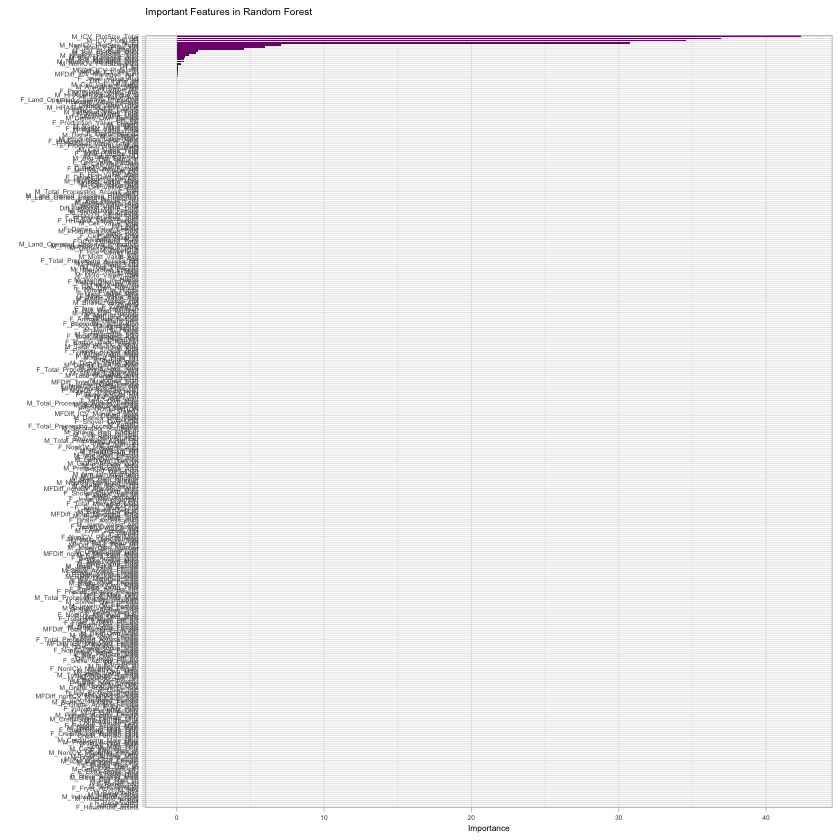

In [30]:


# Plot feature importance
#Author DataFlair
plot_ <- ggplot(Important_Features, 
    aes(x= reorder(Feature,
Importance) , y = Importance) ) +
geom_bar(stat = "identity", 
        fill = "#800080") +
coord_flip() +
theme_light(base_size = 9) +
xlab("") + 
ylab("Importance")+
ggtitle("Important Features in Random Forest\n") +
theme(text = element_text(size=5))
plot_

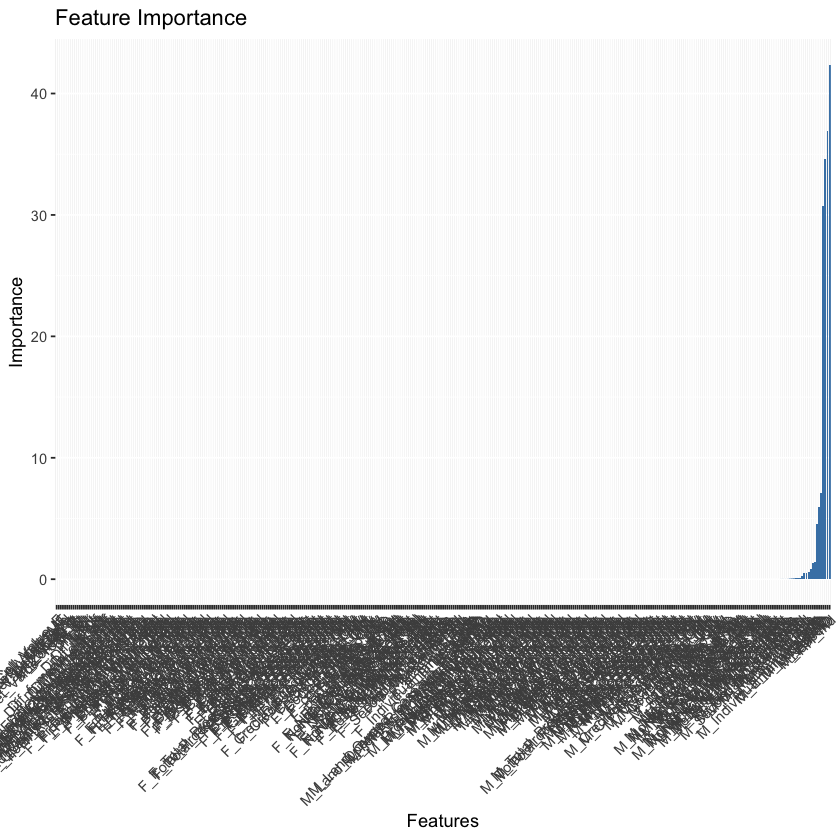

In [31]:
# Plot feature importance
ggplot(Important_Features, aes(x = reorder(rownames(importance), Importance), y = Importance)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  xlab("Features") +
  ylab("Importance") +
  ggtitle("Feature Importance") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))